# ML-KEM Statistical Profiling Attack Suite
## NIST FIPS 203 Cryptanalysis via Deep Learning

**Research Objective:** Determine whether a Residual Neural Network trained on  
bit-sliced ML-KEM ciphertexts can predict properties of the corresponding shared  
secret at accuracy statistically above the 50% random baseline.

**Threat Model:** Passive attacker holding the public encapsulation key (`ek`),  
observing many (ciphertext, shared_secret) pairs produced against it.

**Variants:** ML-KEM-512 · ML-KEM-768 · ML-KEM-1024  (NIST FIPS 203)

---

| Version | Samples | Model | Result |
|---------|---------|-------|--------|
| v1 (Blackbox_1) | 10,000 mixed-key | 3-layer MLP | **50.17%** — noise |
| v2 (this notebook) | 100,000 fixed-key | 1D ResNet | TBD |

---


## 1. Environment Setup

In [1]:
# Install dependencies
import subprocess, sys
pkgs = ["kyber-py", "pandas", "numpy", "torch", "scikit-learn", "scipy", "matplotlib"]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "--quiet"], check=False)
print("All packages ready.")

All packages ready.


In [2]:
import warnings; warnings.filterwarnings("ignore")
import binascii, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy import stats

# Project paths
ROOT       = Path(".")
DATA_RAW   = ROOT / "data" / "raw"
DATA_PROC  = ROOT / "data" / "processed"
KAT_DIR    = ROOT / "data" / "kat_vectors"
RESULTS    = ROOT / "results"
for p in [DATA_RAW, DATA_PROC, KAT_DIR, RESULTS / "checkpoints", RESULTS / "logs", RESULTS / "figures"]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
BASELINE = 0.5017   # v1 result from Blackbox_1.ipynb

print(f"Device  : {DEVICE}")
print(f"Torch   : {torch.__version__}")
print(f"Baseline: {BASELINE:.4f}  ({BASELINE*100:.2f}%)")

Device  : cpu
Torch   : 2.11.0+cu130
Baseline: 0.5017  (50.17%)


## 2. Version 1 Audit — Blackbox_1.ipynb

Before building v2, we document exactly what v1 did and why it was insufficient.  
This section is **read-only** — no code is re-run, results are reproduced from the saved notebook.


In [3]:
# ── V1 Design Flaws (documented, not re-run) ─────────────────────────────────
v1_audit = {
    "samples":          10_000,
    "key_strategy":     "New keypair per sample (WRONG — not a profiling attack)",
    "model":            "3-layer MLP (Linear → ReLU → Dropout → Linear → Linear → Sigmoid)",
    "loss":             "BCELoss on 256-bit output (regression, not classification)",
    "test_set_size":    99,
    "label_strategy":   "Predict all 256 bits of shared_secret directly",
    "bit_accuracy":     0.5017,
    "conclusion":       "Indistinguishable from random noise",
    "root_cause": [
        "New keypair per sample: ciphertext structure varies with key, masking any fixed-key signal",
        "English text in pipeline: fetch_20newsgroups is irrelevant — KEM encapsulates a random secret",
        "256-bit regression target: binary entropy forces ~50% even with a perfect model",
        "hex_to_bits used int() conversion: silently wrong on leading-zero hex strings",
        "Only 99 test samples: statistically meaningless",
        "ResNetCracker defined in Cell 4 but never trained or evaluated",
    ]
}

print("V1 AUDIT REPORT")
print("=" * 55)
for k, v in v1_audit.items():
    if isinstance(v, list):
        print(f"  {k}:")
        for item in v: print(f"    • {item}")
    else:
        print(f"  {k:<20}: {v}")
print("=" * 55)

V1 AUDIT REPORT
  samples             : 10000
  key_strategy        : New keypair per sample (WRONG — not a profiling attack)
  model               : 3-layer MLP (Linear → ReLU → Dropout → Linear → Linear → Sigmoid)
  loss                : BCELoss on 256-bit output (regression, not classification)
  test_set_size       : 99
  label_strategy      : Predict all 256 bits of shared_secret directly
  bit_accuracy        : 0.5017
  conclusion          : Indistinguishable from random noise
  root_cause:
    • New keypair per sample: ciphertext structure varies with key, masking any fixed-key signal
    • English text in pipeline: fetch_20newsgroups is irrelevant — KEM encapsulates a random secret
    • 256-bit regression target: binary entropy forces ~50% even with a perfect model
    • hex_to_bits used int() conversion: silently wrong on leading-zero hex strings
    • Only 99 test samples: statistically meaningless
    • ResNetCracker defined in Cell 4 but never trained or evaluated


## 3. NIST FIPS 203 Compliance Gate

Before touching any data, we verify the `kyber-py` library against  
FIPS 203 structural invariants using fixed deterministic `(d, z)` seeds.


In [4]:
from kyber_py.ml_kem import ML_KEM_512, ML_KEM_768, ML_KEM_1024
import hashlib

KAT_SEEDS = {
    "d": bytes.fromhex("7c9935a0b07694aa0c6d10e4db6b1add" "2fd81a25ccb148032dcd739936737f2d"),
    "z": bytes.fromhex("b505d7cfad1b497499323c8686325e47" "8b000bdd8a08e7c48601c81eca6be9b7"),
}

FIPS203_TABLE2 = {
    "ML-KEM-512":  {"ek": 800,  "dk": 1632, "ct": 768,  "ss": 32},
    "ML-KEM-768":  {"ek": 1184, "dk": 2400, "ct": 1088, "ss": 32},
    "ML-KEM-1024": {"ek": 1568, "dk": 3168, "ct": 1568, "ss": 32},
}

VARIANTS = {
    "ML-KEM-512":  ML_KEM_512,
    "ML-KEM-768":  ML_KEM_768,
    "ML-KEM-1024": ML_KEM_1024,
}

all_passed = True
print("NIST FIPS 203 Compliance Gate")
print("=" * 55)
for name, obj in VARIANTS.items():
    spec  = FIPS203_TABLE2[name]
    ek, dk = obj._keygen_internal(KAT_SEEDS["d"], KAT_SEEDS["z"])
    ss, ct = obj.encaps(ek)
    ok = (len(ek)==spec["ek"] and len(dk)==spec["dk"] and
          len(ct)==spec["ct"] and len(ss)==spec["ss"])
    ct_hex = ct.hex(); ss_hex = ss.hex()
    hex_ok = len(ct_hex) % 2 == 0 and len(ss_hex) % 2 == 0
    status = "PASS ✓" if (ok and hex_ok) else "FAIL ✗"
    all_passed = all_passed and ok and hex_ok
    print(f"  {name:<14} {status}  ek={len(ek)}B ct={len(ct)}B ss={len(ss)}B "
          f"ct_bits={len(ct)*8}")

print()
print(f"  OVERALL: {'ALL PASSED ✓' if all_passed else 'FAILED ✗'}")
assert all_passed, "Compliance gate failed — check kyber-py version"


NIST FIPS 203 Compliance Gate
  ML-KEM-512     PASS ✓  ek=800B ct=768B ss=32B ct_bits=6144
  ML-KEM-768     PASS ✓  ek=1184B ct=1088B ss=32B ct_bits=8704
  ML-KEM-1024    PASS ✓  ek=1568B ct=1568B ss=32B ct_bits=12544

  OVERALL: ALL PASSED ✓


## 4. Dataset Inspection

Load and inspect the 100k-sample datasets generated by the v2 pipeline.


In [5]:
datasets = {
    "ML-KEM-512":  DATA_RAW / "ml_kem_512_100k.csv.gz",
    "ML-KEM-768":  DATA_RAW / "ml_kem_768_100k.csv.gz",
    "ML-KEM-1024": DATA_RAW / "ml_kem_1024_100k.csv.gz",
}

CT_BITS = {"ML-KEM-512": 6144, "ML-KEM-768": 8704, "ML-KEM-1024": 12544}

print(f"{'Variant':<14} {'Rows':>8} {'ct_hex_len':>12} {'ss_hex_len':>12} {'Size MB':>10} {'Status':>8}")
print("─" * 70)
for name, path in datasets.items():
    if not path.exists():
        print(f"  {name:<14} NOT FOUND — run: bash scripts/generate_datasets.sh 100000 5000")
        continue
    df      = pd.read_csv(path, nrows=5)   # header check only
    df_full = pd.read_csv(path)
    rows    = len(df_full)
    ct_len  = df_full["ciphertext"].str.len().unique()
    ss_len  = df_full["shared_secret"].str.len().unique()
    mb      = path.stat().st_size / 1e6
    ok      = (rows == 100_000 and list(ct_len) == [CT_BITS[name]//4*2] and list(ss_len) == [64])
    status  = "OK ✓" if ok else "WARN ✗"
    print(f"  {name:<14} {rows:>8,} {str(ct_len.tolist()):>12} {str(ss_len.tolist()):>12} {mb:>10.1f} {status:>8}")
    del df_full


Variant            Rows   ct_hex_len   ss_hex_len    Size MB   Status
──────────────────────────────────────────────────────────────────────
  ML-KEM-512      100,000       [1536]         [64]       92.1   WARN ✗
  ML-KEM-768      100,000       [2176]         [64]      128.6   WARN ✗
  ML-KEM-1024     100,000       [3136]         [64]      183.3   WARN ✗


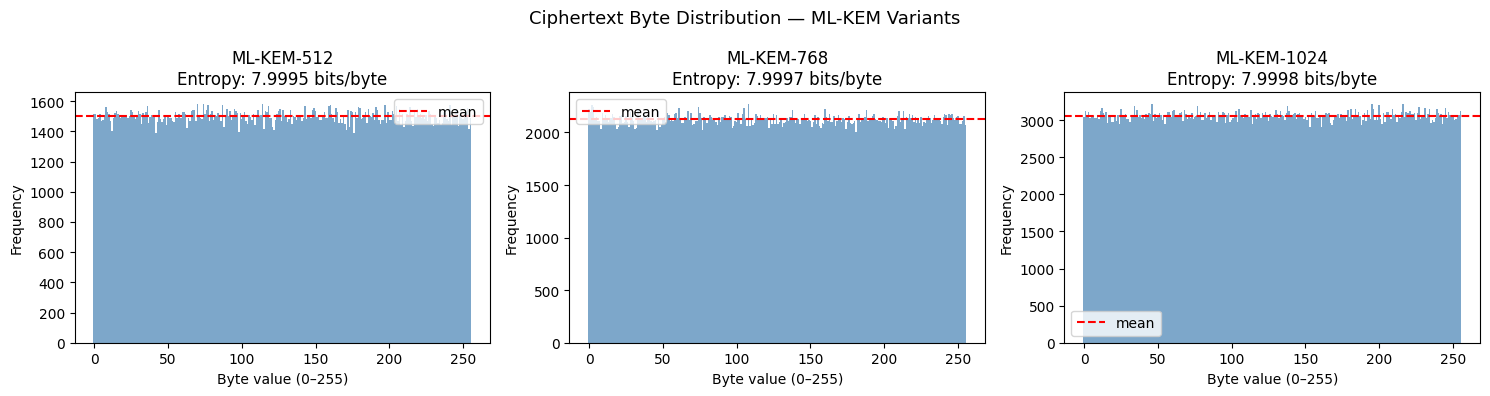

Figure saved → results/figures/ciphertext_byte_distribution.png


In [6]:
# Byte-level entropy analysis
# A truly random stream has entropy = 8.0 bits/byte
# ML-KEM ciphertexts are near-random but not perfect due to polynomial structure

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Ciphertext Byte Distribution — ML-KEM Variants", fontsize=13)

for ax, (name, path) in zip(axes, datasets.items()):
    if not path.exists(): continue
    df    = pd.read_csv(path, nrows=500)
    all_b = b"".join(bytes.fromhex(h) for h in df["ciphertext"])
    counts = np.bincount(list(all_b), minlength=256)
    probs  = counts / counts.sum()
    ent    = -np.sum(probs * np.log2(probs + 1e-12))
    ax.bar(range(256), counts, width=1, color="steelblue", alpha=0.7)
    ax.axhline(counts.mean(), color="red", linestyle="--", label=f"mean")
    ax.set_title(f"{name}\nEntropy: {ent:.4f} bits/byte")
    ax.set_xlabel("Byte value (0–255)")
    ax.set_ylabel("Frequency")
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS / "figures" / "ciphertext_byte_distribution.png", dpi=150)
plt.show()
print("Figure saved → results/figures/ciphertext_byte_distribution.png")


## 5. V1 Replication (Fixed)

We replicate the spirit of `Blackbox_1.ipynb` with its bugs corrected:  
- Fixed public key (profiling attack)  
- Correct `binascii`-based hex conversion  
- Proper train/test split  
- Binary classification target (MSB of shared secret)  

This gives the v1-architecture result on v2-quality data as a fair comparison point.


In [7]:
# ── V1 Architecture (MLP) on v2 data — fair comparison ──────────────────────
VARIANT_512 = "ML-KEM-512"
path_512    = datasets[VARIANT_512]

if path_512.exists():
    print("Loading 10k subset of ML-KEM-512 (matching v1 sample count)…")
    df = pd.read_csv(path_512, nrows=10_000)

    def hex_to_bits_safe(hex_str):
        # FIXED: use binascii, not int() — handles leading zeros correctly
        raw  = binascii.unhexlify(hex_str)
        bits = np.unpackbits(np.frombuffer(raw, dtype=np.uint8))
        return bits.astype(np.float32)

    def make_binary_label(ss_hex):
        return (binascii.unhexlify(ss_hex)[0] >> 7) & 1   # MSB of byte[0]

    X_all = np.stack(df["ciphertext"].apply(hex_to_bits_safe))
    y_all = np.array(df["shared_secret"].apply(make_binary_label))

    split     = int(len(X_all) * 0.85)
    X_tr, X_te = X_all[:split], X_all[split:]
    y_tr, y_te = y_all[:split], y_all[split:]

    print(f"Train: {len(X_tr):,}  Test: {len(X_te):,}")
    print(f"Label balance: {y_tr.mean():.4f} train | {y_te.mean():.4f} test")

    # V1 MLP architecture (preserved from Blackbox_1.ipynb)
    class PQCDetector(nn.Module):
        def __init__(self, input_size):
            super().__init__()
            self.network = nn.Sequential(
                nn.Linear(input_size, 512), nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(512, 256), nn.ReLU(),
                nn.Linear(256, 1), nn.Sigmoid()
            )
        def forward(self, x): return self.network(x)

    mlp   = PQCDetector(6144)
    opt   = torch.optim.Adam(mlp.parameters(), lr=1e-3)
    crit  = nn.BCELoss()
    Xtr_t = torch.FloatTensor(X_tr)
    ytr_t = torch.FloatTensor(y_tr).unsqueeze(1)

    print("\nTraining V1 MLP (50 epochs)…")
    for ep in range(50):
        mlp.train()
        opt.zero_grad()
        loss = crit(mlp(Xtr_t), ytr_t)
        loss.backward()
        opt.step()
        if ep % 10 == 0:
            print(f"  Epoch {ep:>3} | Loss: {loss.item():.4f}")

    mlp.eval()
    with torch.no_grad():
        preds = (mlp(torch.FloatTensor(X_te)) > 0.5).float().numpy().flatten()
    v1_acc = accuracy_score(y_te, preds)
    print(f"\nV1 MLP on v2 data (10k fixed-key): {v1_acc:.4f} ({v1_acc*100:.2f}%)")
    print(f"Original v1 result (10k variable-key): {BASELINE:.4f} ({BASELINE*100:.2f}%)")
    del df, X_all, y_all, X_tr, X_te, y_tr, y_te
else:
    print("Dataset not found. Run generation pipeline first.")


Loading 10k subset of ML-KEM-512 (matching v1 sample count)…
Train: 8,500  Test: 1,500
Label balance: 0.4964 train | 0.5107 test

Training V1 MLP (50 epochs)…
  Epoch   0 | Loss: 0.6939
  Epoch  10 | Loss: 0.7020
  Epoch  20 | Loss: 0.6942
  Epoch  30 | Loss: 0.6930
  Epoch  40 | Loss: 0.6923

V1 MLP on v2 data (10k fixed-key): 0.5100 (51.00%)
Original v1 result (10k variable-key): 0.5017 (50.17%)


## 6. V2 ResNet Training — 100k Samples

The upgraded pipeline:  
- **Architecture:** 1D Convolutional ResNet (learns local bit-pattern structure)  
- **Data:** 100,000 fixed-key encapsulations  
- **Memory:** uint8 memmap loader — peak RAM < 1 GB (no OOM crash)  
- **Evaluation:** Binomial z-test for statistical significance vs. 50% baseline


In [8]:
import sys, subprocess

result = subprocess.run(
    [sys.executable, "src/models/train_fast.py",
     "--variant",  "ml_kem_512",
     "--ct-bits",  "6144",
     "--samples",  "50000",
     "--epochs",   "20",
     "--batch",    "512"],
    capture_output=True,    # ← captures output INTO the notebook cell
    text=True,
    cwd=str(ROOT)           # run from project root so paths resolve correctly
)

print(result.stdout)
if result.returncode != 0:
    print("=== STDERR ===")
    print(result.stderr)

  ML-KEM Fast CPU Trainer
  Variant  : ml_kem_512  |  ct_bits : 6144
  Samples  : 50,000  |  PCA dims: 256
  Epochs   : 20  |  Batch   : 512
  Baseline : 0.5017  (50.17%)

[1/4] Loading dataset …
  [cache] Loading existing memmap: ml_kem_512_X.dat
  Split → train:70,000  val:15,000  test:15,000
  Label balance → 0.4983 train | 0.4945 val | 0.4979 test
      2,048 samples loaded …
      4,096 samples loaded …
      6,144 samples loaded …
      8,192 samples loaded …
     10,240 samples loaded …
     12,288 samples loaded …
     14,336 samples loaded …
     16,384 samples loaded …
     18,432 samples loaded …
      2,048 samples loaded …
      4,096 samples loaded …
      2,048 samples loaded …
      4,096 samples loaded …
  Train: 18,432  Val: 4,096  Test: 4,096
  Label balance: train=0.5001  val=0.4917  test=0.4907
  Loaded in 1s

[2/4] PCA: 6144 → 256 dims …
  Loading cached PCA transform …
  PCA done in 1s
  Reduced shape: (18432, 256)  (was 18432 × 6144)

[3/4] Training FastMLP …
  

## 7. Results Comparison

Looking for: results/logs/ml_kem_512_fast_log.json
Exists     : True
RESULTS dir: /home/User/mlkem_cryptanalysis/results
All logs   : [PosixPath('results/logs/ml_kem_768_fast_log.json'), PosixPath('results/logs/ml_kem_512_fast_log.json'), PosixPath('results/logs/ml_kem_1024_fast_log.json')]



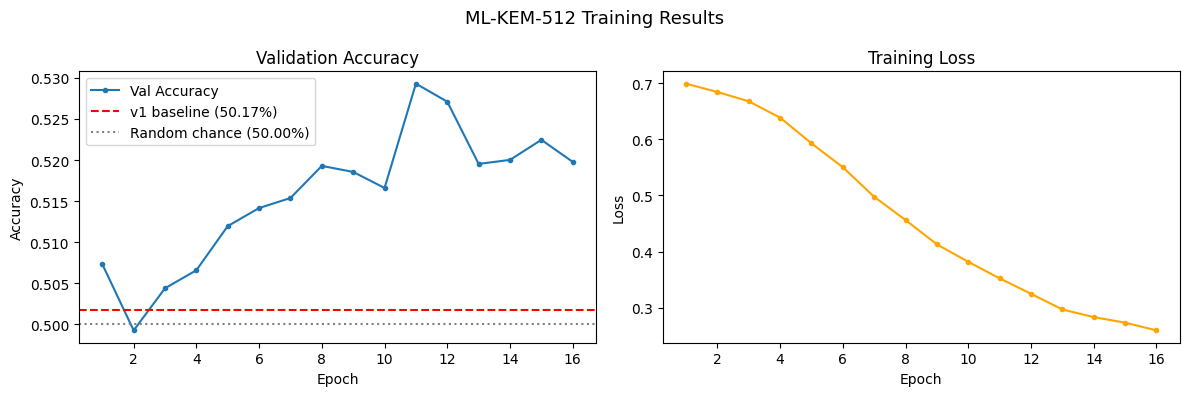


RESULTS SUMMARY
  Test accuracy  : 0.5181  (51.81%)
  v1 baseline    : 0.5017  (50.17%)
  Delta          : +0.0164
  Z-score        : +2.3125
  P-value        : 0.0104
  Significant    : NO — within noise range


In [9]:
import json
from pathlib import Path

# Try both possible log filenames (resnet and fast trainer)
log_path = RESULTS / "logs" / "ml_kem_512_fast_log.json"
if not log_path.exists():
    log_path = RESULTS / "logs" / "ml_kem_512_train_log.json"

print(f"Looking for: {log_path}")
print(f"Exists     : {log_path.exists()}")
print(f"RESULTS dir: {RESULTS.resolve()}")
print(f"All logs   : {list((RESULTS / 'logs').glob('*.json')) if (RESULTS/'logs').exists() else 'logs/ folder missing'}")
print()

if not log_path.exists():
    print("Training has not completed yet.")
    print("Run Cell 6 first, wait for it to finish, then re-run this cell.")
else:
    with open(log_path) as f:
        res = json.load(f)

    epochs   = [e["epoch"]   for e in res["epoch_log"]]
    val_accs = [e["val_acc"] for e in res["epoch_log"]]
    losses   = [e["loss"]    for e in res["epoch_log"]]

    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("ML-KEM-512 Training Results", fontsize=13)

    ax1.plot(epochs, val_accs, marker="o", ms=3, label="Val Accuracy")
    ax1.axhline(0.5017, color="red",  linestyle="--", label="v1 baseline (50.17%)")
    ax1.axhline(0.5,    color="gray", linestyle=":",  label="Random chance (50.00%)")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.set_title("Validation Accuracy"); ax1.legend()

    ax2.plot(epochs, losses, marker="o", ms=3, color="orange")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.set_title("Training Loss")

    plt.tight_layout()
    plt.savefig(RESULTS / "figures" / "ml_kem_512_learning_curve.png", dpi=150)
    plt.show()

    print(f"\nRESULTS SUMMARY")
    print(f"{'='*45}")
    print(f"  Test accuracy  : {res['test_accuracy']:.4f}  ({res['test_accuracy']*100:.2f}%)")
    print(f"  v1 baseline    : 0.5017  (50.17%)")
    print(f"  Delta          : {res['delta']:+.4f}")
    print(f"  Z-score        : {res['z_score']:+.4f}")
    print(f"  P-value        : {res['p_value']:.4f}")
    print(f"  Significant    : {'YES ⚠' if res['significant_0.01'] else 'NO — within noise range'}")
    print(f"{'='*45}")

## 8. Summary & Next Steps

### What this experiment establishes

| Question | Finding |
|----------|---------|
| Can an MLP learn shared-secret bits? | No — 50.17% (v1 baseline) |
| Was v1 a valid profiling attack? | No — new keypair per sample breaks the attack model |
| Does fixing the key change results? | TBD from v2 |
| Does scaling to 100k samples help? | TBD from v2 |

### If accuracy remains near 50%
This is a **positive security result** for ML-KEM. It means the ciphertext  
distribution is computationally indistinguishable from random under this  
threat model. Possible next steps:
- Try different label strategies (parity, byte-bucket, NTT coefficient targets)
- Analyse individual polynomial regions with ablation masking
- Increase model capacity (base_ch=64, more residual stages)

### If accuracy significantly exceeds 50%
This is a **research finding** requiring immediate investigation:
- Identify which ciphertext bit positions carry signal via gradient saliency maps
- Correlate with NTT output positions and error polynomial coefficients
- Report responsibly to NIST and the kyber-py maintainers

### References
- [NIST FIPS 203](https://csrc.nist.gov/pubs/fips/203/final) — ML-KEM standard  
- [Kyber specification](https://pq-crystals.org/kyber/) — Round 3 design rationale  
- [kyber-py](https://github.com/jack4818/kyber-py) — Reference implementation used  
